# Vórtice — gráficos de una medición

Lee una carpeta de `fluido/data/` (`*_track.csv` + `*_meta.json`) y grafica la trayectoria
de la partícula, el centro del vórtice y las velocidades.

Convención (ver `../README.md`): cámara **A** = vista superior → plano horizontal
(`x`, `y`); cámara **B** = vista lateral → altura (`z`). Si la medición sigue varias
partículas, cada una es un sufijo `p1`, `p2`, … y podés usar una como centro del vórtice.

In [56]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

fontsize = 13
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)

DATA = Path("../data")


def mediciones():
    """Carpetas de ../data que tienen un CSV, de la mas vieja a la mas nueva."""
    return sorted((p for p in DATA.iterdir() if p.is_dir() and any(p.glob("*_track.csv"))),
                  key=lambda p: p.stat().st_mtime)


def elegir(cual=-1):
    """cual: indice de la lista (-1 = la mas reciente), parte del nombre, o una ruta."""
    cs = mediciones()
    if isinstance(cual, int):
        return cs[cual]
    if Path(cual).is_dir():
        return Path(cual)
    coincide = [c for c in cs if str(cual).lower() in c.name.lower()]
    if not coincide:
        raise FileNotFoundError(f"nada coincide con {cual!r}. Hay: {[c.name for c in cs]}")
    return coincide[-1]


def cargar(carpeta):
    """CSV + JSON de una medicion, con los nombres de columna de la version nueva."""
    df = pd.read_csv(next(carpeta.glob("*_track.csv")))
    meta = json.loads(next(carpeta.glob("*_meta.json")).read_text(encoding="utf-8"))
    if "a_ok" in df.columns:   # formato viejo: una sola particula, sin sufijo p1
        df = df.rename(columns=lambda c: f"{c[:2]}p1_{c[2:]}" if c[:2] in ("a_", "b_") else c)
    return df, meta


def particulas(df, cam="a"):
    """Numeros de particula que trae el CSV para esa camara."""
    return sorted({int(c.split("_")[1][1:]) for c in df.columns
                   if c.startswith(f"{cam}_p") and c.endswith("_ok")})


for i, p in enumerate(mediciones()):
    print(f"[{i:2d}]  {p.name}")

[ 0]  verde mini run1
[ 1]  amarillas_2_2
[ 2]  amarillas_2_teca


## Elegir qué graficar

Todo lo que hay que tocar está en esta celda: qué medición, qué partícula se analiza y qué
se usa como centro del vórtice.

- `CARPETA` — el índice de la lista de arriba (`-1` = la más reciente), parte del nombre
  (`"amarillas"`) o una ruta completa.
- `PARTICULA` — cuál de las partículas seguidas es la que orbita y se analiza.
- `CENTRO` — el número de **otra partícula** que se queda quieta en el eje del vórtice y
  marca el centro cuadro a cuadro, o `"final"` para usar el promedio de las últimas
  `N_CENTRO` posiciones de la partícula analizada (cuando ésta termina cayendo al centro).

In [71]:
CARPETA   = "amarillas_2_2"   # indice, parte del nombre, o ruta
PARTICULA = 1                    # particula que se analiza
CENTRO    = 2                    # numero de particula que marca el centro, o "final"
N_CENTRO  = 30                   # cuadros del final a promediar, solo si CENTRO == "final"
DT_CORTE_S = 0.5                 # dt mayor a esto = hueco: no se deriva a traves

carpeta = elegir(CARPETA)
df, meta = cargar(carpeta)

print(f"carpeta  : {carpeta.name}")
print(f"medicion : {meta.get('medicion', '?')}  ({meta.get('fecha', '?')})")
print(f"cuadros  : {len(df)} en {df['t_s'].max():.1f} s  ->  {meta.get('fps_efectivo', 0):.2f} fps")
if "velocidad_agitador_rpm" in meta:
    print(f"agitador : {meta['velocidad_agitador_rpm']:.0f} rpm")
for cam in ("a", "b"):
    for p in particulas(df, cam):
        print(f"deteccion {cam.upper()} p{p}: {100 * (df[f'{cam}_p{p}_ok'] == 1).mean():5.1f} %")
print(f"dt       : mediano {1e3*meta.get('dt_mediano_s', 0):.1f} ms, "
      f"maximo {meta.get('dt_maximo_s', 0):.2f} s, "
      f"desvio {1e3*meta.get('dt_desvio_s', 0):.1f} ms, saltos {meta.get('saltos', '?')}")
for cam, clave in (("A", "cam_a_vista_superior"), ("B", "cam_b_vista_lateral")):
    esc = meta.get(clave, {}).get("calibracion", {}).get("escala_mm_por_px")
    if esc:
        print(f"escala {cam} : {esc:.4f} mm/px  ({meta[clave].get('origen', '?')})")

df.head()

carpeta  : amarillas_2_2
medicion : amarillas_2  (2026-09-10_191504)
cuadros  : 1665 en 68.1 s  ->  24.45 fps
agitador : 1600 rpm
deteccion A p1: 100.0 %
deteccion A p2:  99.9 %
deteccion B p1:   0.0 %
deteccion B p2:   0.0 %
dt       : mediano 33.3 ms, maximo 1.19 s, desvio 92.8 ms, saltos 11
escala A : 0.1079 mm/px  (camera)
escala B : 0.4167 mm/px  (off)


,frame,t_s,t_b_s,a_p1_ok,a_p1_x_px,a_p1_y_px,a_p1_x_mm,a_p1_y_mm,a_p1_area,a_p2_ok,...,b_p1_z_px,b_p1_h_mm,b_p1_z_mm,b_p1_area,b_p2_ok,b_p2_h_px,b_p2_z_px,b_p2_h_mm,b_p2_z_mm,b_p2_area
0,1,0.000000,0.000000,1,854.808105,761.397888,92.198769,82.123634,96,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
1,5,0.033325,0.033325,1,819.340271,764.879456,88.373245,82.499153,105,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
2,7,0.066650,0.066650,1,783.882751,762.865356,84.548828,82.281914,99,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
3,9,0.099976,0.099976,1,746.807068,755.848938,80.549881,81.525124,95,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
4,13,0.133301,0.133301,1,713.730713,745.023376,76.982300,80.357498,103,1,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0


## 1. El tiempo

Antes de derivar velocidades conviene mirar el jitter cuadro a cuadro: si `dt` se dispara,
derivar entre cuadros consecutivos da ruido. Los huecos (`dt > DT_CORTE_S`) se excluyen
después, al calcular las velocidades.

dt mediano : 33.3 ms
huecos     : 11 con dt > 0.5 s (el mayor, 1.2 s en t = 36.1 s)


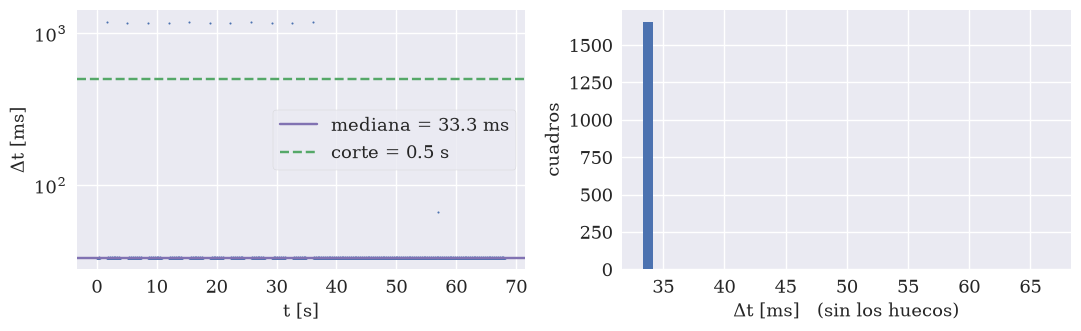

In [72]:
t_todos = df["t_s"].to_numpy()
dt = np.diff(t_todos)
huecos = dt > DT_CORTE_S

print(f"dt mediano : {1e3*np.median(dt):.1f} ms")
print(f"huecos     : {huecos.sum()} con dt > {DT_CORTE_S} s"
      + (f" (el mayor, {dt.max():.1f} s en t = {t_todos[1:][dt.argmax()]:.1f} s)" if huecos.any() else ""))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

ax1.plot(t_todos[1:], 1e3 * dt, ".", ms=3)
ax1.axhline(1e3 * np.median(dt), color="C3", label=f"mediana = {1e3*np.median(dt):.1f} ms")
ax1.axhline(1e3 * DT_CORTE_S, color="C1", ls="--", label=f"corte = {DT_CORTE_S} s")
ax1.set_yscale("log")
ax1.set_xlabel("t [s]")
ax1.set_ylabel("$\\Delta t$ [ms]")
ax1.legend()

ax2.hist(1e3 * dt[~huecos], bins=40)
ax2.set_xlabel("$\\Delta t$ [ms]   (sin los huecos)")
ax2.set_ylabel("cuadros")

fig.tight_layout()
plt.show()

## 2. Trayectoria

La partícula analizada va coloreada por tiempo; las otras, en gris.

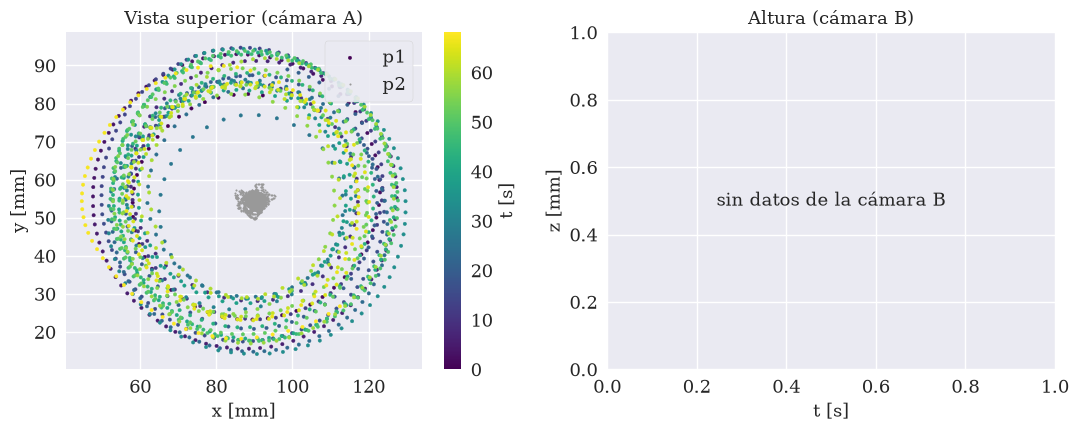

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

for p in particulas(df, "a"):
    m = df[f"a_p{p}_ok"] == 1
    if p == PARTICULA:
        s = ax1.scatter(df.loc[m, f"a_p{p}_x_mm"], df.loc[m, f"a_p{p}_y_mm"],
                        c=df.loc[m, "t_s"], s=6, cmap="viridis", zorder=3, label=f"p{p}")
        fig.colorbar(s, ax=ax1, label="t [s]")
    else:
        ax1.plot(df.loc[m, f"a_p{p}_x_mm"], df.loc[m, f"a_p{p}_y_mm"], ".", ms=3,
                 color="0.6", label=f"p{p}")
ax1.set_aspect("equal")
ax1.set_xlabel("x [mm]")
ax1.set_ylabel("y [mm]")
ax1.set_title("Vista superior (cámara A)")
ax1.legend(loc="upper right", framealpha=0.9)

hay_b = False
for p in particulas(df, "b"):
    m = df[f"b_p{p}_ok"] == 1
    if m.any():
        hay_b = True
        ax2.plot(df.loc[m, "t_s"], df.loc[m, f"b_p{p}_z_mm"], lw=1, label=f"p{p}")
if hay_b:
    ax2.legend()
else:
    ax2.text(0.5, 0.5, "sin datos de la cámara B", ha="center", va="center",
             transform=ax2.transAxes)
ax2.set_xlabel("t [s]")
ax2.set_ylabel("z [mm]")
ax2.set_title("Altura (cámara B)")

fig.tight_layout()
plt.show()

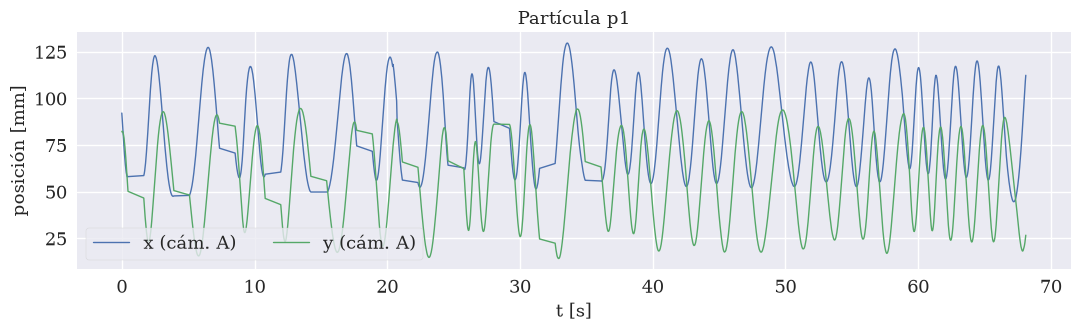

In [74]:
# las coordenadas de la particula analizada contra el tiempo
m = df[f"a_p{PARTICULA}_ok"] == 1

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(df.loc[m, "t_s"], df.loc[m, f"a_p{PARTICULA}_x_mm"], lw=1, label="x (cám. A)")
ax.plot(df.loc[m, "t_s"], df.loc[m, f"a_p{PARTICULA}_y_mm"], lw=1, label="y (cám. A)")
if f"b_p{PARTICULA}_z_mm" in df.columns and (df[f"b_p{PARTICULA}_ok"] == 1).any():
    mb = df[f"b_p{PARTICULA}_ok"] == 1
    ax.plot(df.loc[mb, "t_s"], df.loc[mb, f"b_p{PARTICULA}_z_mm"], lw=1, label="z (cám. B)")
ax.set_xlabel("t [s]")
ax.set_ylabel("posición [mm]")
ax.set_title(f"Partícula p{PARTICULA}")
ax.legend(ncol=3)
fig.tight_layout()
plt.show()

## 3. Centro del vórtice

El programa entrega posiciones absolutas respecto del borde de la imagen, así que el centro
se define acá, según `CENTRO`:

- **otra partícula** (`CENTRO = 2`) — el centro es su posición **cuadro a cuadro**, así que
  cualquier deriva de la partícula quieta o de la cámara se cancela sola. Sólo se usan los
  cuadros donde las dos partículas fueron detectadas, y las velocidades salen en el sistema
  de la partícula-centro (se le resta su propia velocidad).
- **`"final"`** — promedio de las últimas `N_CENTRO` posiciones de la partícula analizada,
  para las mediciones donde ésta termina cayendo al eje y quedándose quieta ahí.

En los dos casos se imprime la **dispersión** del centro: cuánto se movió el punto que se
está usando como origen. Es la incerteza del centro.

centro     : particula p2, cuadro a cuadro
posicion media: (89.88, 54.24) mm
dispersion : mediana 1.83 mm, maxima 5.61 mm
cuadros utiles: 1664 de 1665


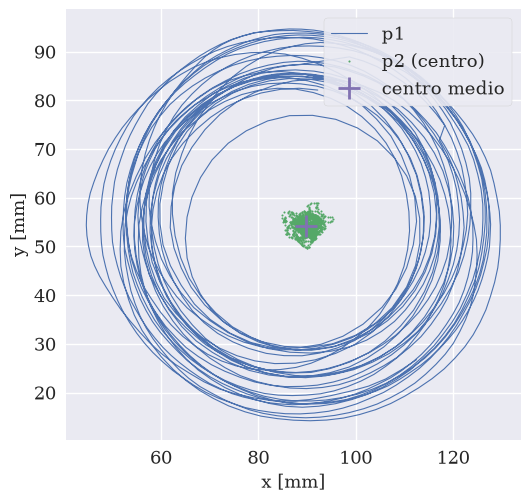

In [75]:
usa_particula = CENTRO != "final"

ok = df[f"a_p{PARTICULA}_ok"] == 1
if usa_particula:
    ok &= df[f"a_p{CENTRO}_ok"] == 1

t = df.loc[ok, "t_s"].to_numpy()
x = df.loc[ok, f"a_p{PARTICULA}_x_mm"].to_numpy()
y = df.loc[ok, f"a_p{PARTICULA}_y_mm"].to_numpy()

if usa_particula:
    cx = df.loc[ok, f"a_p{CENTRO}_x_mm"].to_numpy()   # centro cuadro a cuadro
    cy = df.loc[ok, f"a_p{CENTRO}_y_mm"].to_numpy()
    disp = np.hypot(cx - cx.mean(), cy - cy.mean())
    print(f"centro     : particula p{CENTRO}, cuadro a cuadro")
    print(f"posicion media: ({cx.mean():.2f}, {cy.mean():.2f}) mm")
else:
    cx, cy = x[-N_CENTRO:].mean(), y[-N_CENTRO:].mean()
    disp = np.hypot(x[-N_CENTRO:] - cx, y[-N_CENTRO:] - cy)
    print(f"centro     : ({cx:.2f}, {cy:.2f}) mm")
    print(f"promediando: ultimos {N_CENTRO} cuadros, t = {t[-N_CENTRO]:.2f} - {t[-1]:.2f} s")

print(f"dispersion : mediana {np.median(disp):.2f} mm, maxima {disp.max():.2f} mm")
print(f"cuadros utiles: {ok.sum()} de {len(df)}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(x, y, lw=0.8, color="C0", label=f"p{PARTICULA}")
if usa_particula:
    ax.plot(cx, cy, ".", ms=3, color="C1", zorder=4, label=f"p{CENTRO} (centro)")
    ax.plot(cx.mean(), cy.mean(), "+", ms=16, mew=2, color="C3", zorder=5, label="centro medio")
else:
    ax.plot(x[-N_CENTRO:], y[-N_CENTRO:], ".", ms=5, color="C1", zorder=4,
            label=f"últimos {N_CENTRO} cuadros")
    ax.plot(cx, cy, "+", ms=16, mew=2, color="C3", zorder=5, label="centro")
ax.set_aspect("equal")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.legend(loc="upper right", framealpha=0.9)
fig.tight_layout()
plt.show()

## 4. Radio, ángulo y velocidades

Con el jitter que tiene `dt` no conviene derivar entre cuadros consecutivos: primero se
suaviza la posición con un promedio móvil de `N_SUAVIZADO` cuadros (poné `1` para no
suavizar) y recién ahí se deriva. Las velocidades quedan en `nan` alrededor de los huecos
de tiempo, así que no aparecen en los gráficos.

In [76]:
N_SUAVIZADO = 5

def suave(v):
    return pd.Series(v).rolling(N_SUAVIZADO, center=True, min_periods=1).mean().to_numpy()

# posicion relativa al centro (si el centro es una particula, esto la sigue cuadro a cuadro)
dx = suave(x - cx)
dy = suave(y - cy)

r = np.hypot(dx, dy)                     # radio [mm]
theta = np.unwrap(np.arctan2(dy, dx))    # angulo acumulado [rad]

vx, vy = np.gradient(dx, t), np.gradient(dy, t)
v_tan = (-vx * dy + vy * dx) / r         # mm/s, el signo da el sentido de giro
v_rad = ( vx * dx + vy * dy) / r         # mm/s, >0 se aleja del centro
omega = v_tan / r                        # rad/s

# no derivar a traves de los huecos de tiempo
malo = np.gradient(t) > DT_CORTE_S
v_tan[malo] = v_rad[malo] = omega[malo] = np.nan

vueltas = (theta[-1] - theta[0]) / (2 * np.pi)
print(f"vueltas dadas   : {vueltas:.2f}  ({'antihorario' if vueltas > 0 else 'horario'})")
print(f"periodo medio   : {(t[-1] - t[0]) / abs(vueltas):.3f} s")
print(f"|v_tan| mediana : {np.nanmedian(np.abs(v_tan)):.1f} mm/s")
print(f"v_rad mediana   : {np.nanmedian(v_rad):.2f} mm/s")
print(f"radio           : {r.min():.1f} - {r.max():.1f} mm")
print(f"descartados por huecos: {malo.sum()} cuadros")

vueltas dadas   : 26.60  (antihorario)
periodo medio   : 2.560 s
|v_tan| mediana : 92.7 mm/s
v_rad mediana   : -0.20 mm/s
radio           : 21.3 - 45.2 mm
descartados por huecos: 22 cuadros


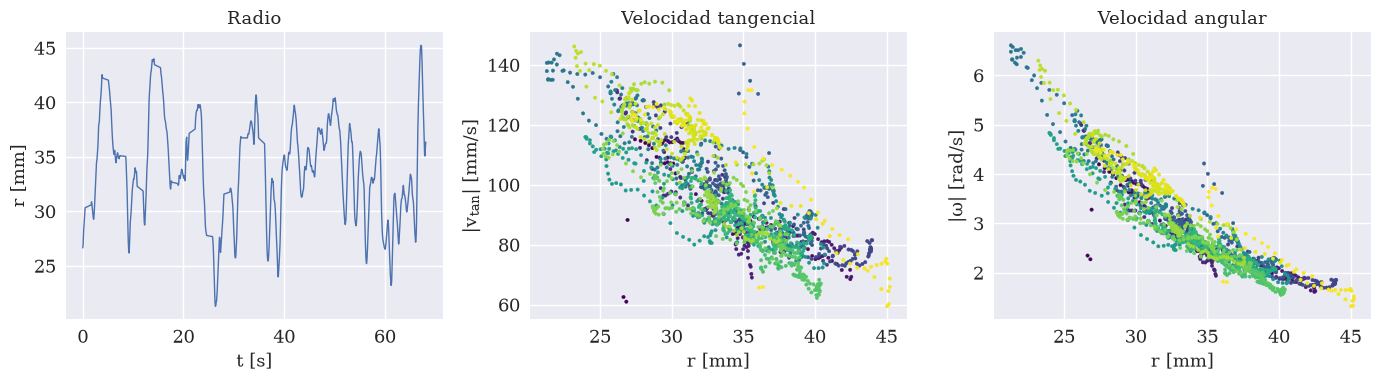

In [77]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(t, r, lw=1)
axs[0].set_xlabel("t [s]")
axs[0].set_ylabel("r [mm]")
axs[0].set_title("Radio")

axs[1].scatter(r, np.abs(v_tan), c=t, s=6, cmap="viridis")
axs[1].set_xlabel("r [mm]")
axs[1].set_ylabel("$|v_{tan}|$ [mm/s]")
axs[1].set_title("Velocidad tangencial")

axs[2].scatter(r, np.abs(omega), c=t, s=6, cmap="viridis")
axs[2].set_xlabel("r [mm]")
axs[2].set_ylabel("$|\\omega|$ [rad/s]")
axs[2].set_title("Velocidad angular")

fig.tight_layout()
plt.show()

### Perfil del vórtice: altura contra radio

Necesita la cámara B: `z` sale de ahí y `r` del plano de la cámara A, así que sólo se usan
los cuadros donde la partícula analizada fue detectada por las dos cámaras.

In [ ]:
col_z = f"b_p{PARTICULA}_z_mm"
ok_z = (df[f"b_p{PARTICULA}_ok"] == 1) & ok if col_z in df.columns else pd.Series(False, index=df.index)

if not ok_z.any():
    print(f"la camara B no detecto la particula p{PARTICULA} en esta medicion. Saltear.")
else:
    t_z = df.loc[ok_z, "t_s"].to_numpy()
    z = df.loc[ok_z, col_z].to_numpy()
    r_z = np.interp(t_z, t, r)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    s = ax.scatter(r_z, z, c=t_z, s=6, cmap="viridis")
    fig.colorbar(s, ax=ax, label="t [s]")
    ax.set_xlabel("r [mm]")
    ax.set_ylabel("z [mm]")
    ax.set_title("Superficie recorrida por la partícula")
    fig.tight_layout()
    plt.show()